# Parameter quality evaluation

In this notebook we evaluate parameter quality on the quantum hardware.

In [1]:
import json
import glob
import matplotlib.pyplot as plt

from qaoa_training_pipeline.utils.graph_utils import load_graph, graph_to_operator

from qaoa_parameter_setting.utils.hardware_execution import HarwareExecutor

The cell below can be used to get a sense of how much data there is for the different graphs. It is optional to run, it helps pick an instance to analyze.

In [2]:
instance_keys = ["30nodes", "random3regular"]
selected_instances = []
folder = "random_regular"
short_name_base = "N30R3R"

for file_name in glob.glob(f"../instances/{folder}/*"):
    file_name = file_name.replace("\\", "/").split("/")[-1]
    selected = all(key in file_name for key in instance_keys)
    if selected:
        selected_instances.append((file_name, file_name[0:3] + short_name_base))

graphs = {inst: load_graph(f"../instances/{folder}/{inst}") for inst, _ in selected_instances}
cost_ops = {inst: graph_to_operator(graph, pre_factor=-0.5) for inst, graph in graphs.items()}

selected_instances

[('000_30nodes_random3regular.json', '000N30R3R'),
 ('001_30nodes_random3regular.json', '001N30R3R'),
 ('002_30nodes_random3regular.json', '002N30R3R'),
 ('003_30nodes_random3regular.json', '003N30R3R'),
 ('004_30nodes_random3regular.json', '004N30R3R'),
 ('005_30nodes_random3regular.json', '005N30R3R'),
 ('006_30nodes_random3regular.json', '006N30R3R'),
 ('007_30nodes_random3regular.json', '007N30R3R'),
 ('008_30nodes_random3regular.json', '008N30R3R'),
 ('009_30nodes_random3regular.json', '009N30R3R')]

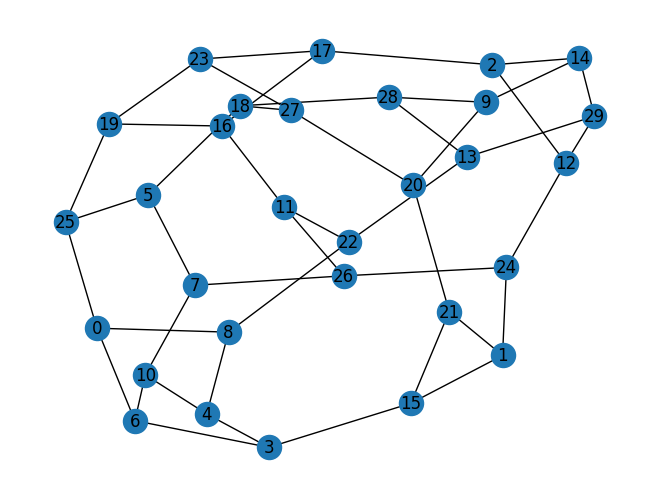

In [3]:
import networkx as nx
nx.draw(graphs["000_30nodes_random3regular.json"], with_labels=True)

In [4]:
executors = []
folder = "random_regular"
for instance, short_name in selected_instances:
    executors.append(HarwareExecutor(instance, short_name, folder, base_path=".."))

C:\Users\DanielEgger\OneDrive - IBM\Documents\qiskit\QAOA-Parameter-Setting\qaoa_parameter_setting\utils\best_parameters.py:132: UserWarning: Result JSON not corrected for TQATrainer bug, for qaoa-training-pipeline<16. Use `fix_saved_tqatrainer.py`.
  warnings.warn(


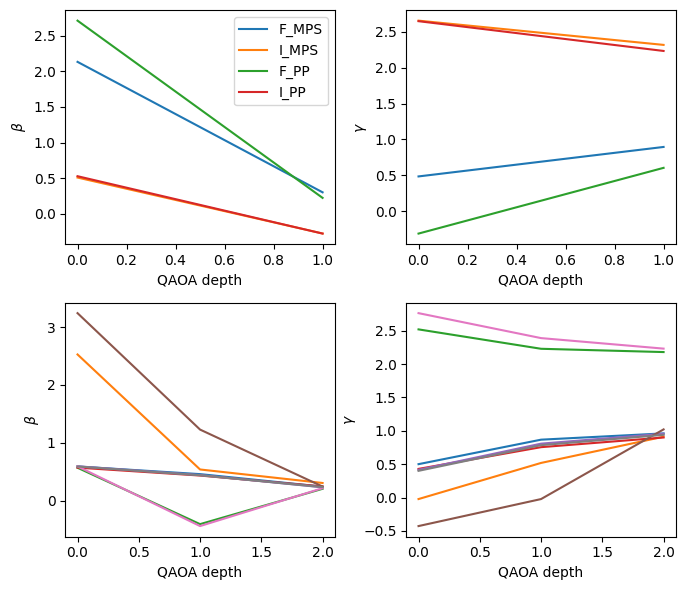

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(7, 6))
executors[1].plot_qaoa_angles(2, fig, axs[0][0], axs[0][1])
executors[1].plot_qaoa_angles(3, fig, axs[1][0], axs[1][1])
axs[0][0].legend()
fig.tight_layout()

### This allows us to manually add angles

In [6]:
from qaoa_training_pipeline.evaluation import MPSAerEvaluator

In [7]:
mps = MPSAerEvaluator()

In [8]:
cal_points = [("zero", [0.001, 0.001, 0.001, 0.001]), ("cal1", [1, 1, 1, 1]), ("cal2", [-1, -1, 1, 1])]

for executor in executors:
    for name, angles in cal_points:
        energy = mps.evaluate(cost_op=cost_ops[selected_instances[0][0]], params=angles)
        executor.manual_add_parameters(angles, energy, name)

In [9]:
executors[0]._all_methods_summary["zero"]

{2: ([0.001, 0.001, 0.001, 0.001], -0.04638671875, 'zero', 'no file')}

In [10]:
executors[0]._all_methods_summary["cal1"]

{2: ([1, 1, 1, 1], -6.71044921875, 'cal1', 'no file')}

In [11]:
executors[9]._all_methods_summary["cal2"]

{2: ([-1, -1, 1, 1], 6.2060546875, 'cal2', 'no file')}

## Build the QAOA circuit

In [12]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

In [13]:
service = QiskitRuntimeService(instance="optimization-premium-us")
backend = service.backend("ibm_miami")

management.get:WARNING:2026-01-13 12:01:23,627: Loading default saved account


In [14]:
pub = []

for executor in executors:
    pub += executor.make_sampler_pub(backend, qaoa_depth=2, problem_class="maxcut")

rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5
rows and cols: 6 5


In [15]:
for idx in range(0, len(pub), 4):
    print("Instruction count:", pub[idx].count_ops())
    print("2Q gate depth:", pub[idx].depth(lambda x: len(x.qubits) > 1))

Instruction count: OrderedDict({'sx': 926, 'rz': 890, 'cz': 492, 'measure': 30})
2Q gate depth: 58
Instruction count: OrderedDict({'sx': 926, 'rz': 890, 'cz': 492, 'measure': 30})
2Q gate depth: 58
Instruction count: OrderedDict({'sx': 895, 'rz': 848, 'cz': 480, 'measure': 30, 'x': 1})
2Q gate depth: 50
Instruction count: OrderedDict({'sx': 895, 'rz': 848, 'cz': 480, 'measure': 30, 'x': 1})
2Q gate depth: 50
Instruction count: OrderedDict({'sx': 891, 'rz': 856, 'cz': 468, 'measure': 30})
2Q gate depth: 62
Instruction count: OrderedDict({'sx': 891, 'rz': 856, 'cz': 468, 'measure': 30})
2Q gate depth: 62
Instruction count: OrderedDict({'sx': 929, 'rz': 891, 'cz': 486, 'measure': 30, 'x': 1})
2Q gate depth: 62
Instruction count: OrderedDict({'sx': 939, 'rz': 881, 'cz': 494, 'measure': 30, 'x': 1})
2Q gate depth: 54
Instruction count: OrderedDict({'sx': 939, 'rz': 881, 'cz': 494, 'measure': 30, 'x': 1})
2Q gate depth: 54
Instruction count: OrderedDict({'sx': 931, 'rz': 881, 'cz': 490, 'mea

In [12]:
pub[0].draw("mpl", fold=False, idle_wires=False)

In [75]:
len(pub)

70

In [14]:
7*5*2

70

### Execute on the hardware

In [16]:
sampler = SamplerV2(mode=backend)

In [17]:
job = sampler.run(pub, shots=2**13)

In [27]:
print(job.status())
print(job.job_id())

DONE
d5j3gd767pic73873kug


Get the result and save it. This is to be run when the job is done.

In [28]:
job_ = service.job("d5j3gd767pic73873kug")

In [29]:
res_summary = executor.save_result_summary(job_)

### Load results from past executions and plot them

In [31]:
short_name = "000N30R3R"
with open(f"../data/hardware/{folder}/{short_name}_d5j3gd767pic73873kug.json", "r") as fin:
    res_summary = json.load(fin)

In [32]:
import numpy as np

from qaoa_training_pipeline.visualization.plotting import plot_cdf
from qaoa_training_pipeline.utils.graph_utils import solve_max_cut

from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost

from qaoa_parameter_setting.utils.analysis import mean_obj, standard_error_mean

To compute performance we need to get the graph and the extremal values of the objective to compute the approximation ratio.

In [33]:
cost_ops.keys()

dict_keys(['000_30nodes_random3regular.json', '001_30nodes_random3regular.json', '002_30nodes_random3regular.json', '003_30nodes_random3regular.json', '004_30nodes_random3regular.json', '005_30nodes_random3regular.json', '006_30nodes_random3regular.json', '007_30nodes_random3regular.json', '008_30nodes_random3regular.json', '009_30nodes_random3regular.json'])

In [34]:
m_cuts = {}
for inst, cost_op in cost_ops.items():
    print(inst)
    max_cut, min_cut, _ = solve_max_cut(cost_op)
    m_cuts[inst] = (max_cut, min_cut)

000_30nodes_random3regular.json
001_30nodes_random3regular.json
002_30nodes_random3regular.json
003_30nodes_random3regular.json
004_30nodes_random3regular.json
005_30nodes_random3regular.json
006_30nodes_random3regular.json
007_30nodes_random3regular.json
008_30nodes_random3regular.json
009_30nodes_random3regular.json


We compare the cumulative distributions of the samples from the methods as well as the mean of these distributions.

In [35]:
mc_costs, means, sems, mc_insts = [], [], [], []

for res in res_summary:
    inst = res_summary[0]["metadata"]["circuit_metadata"]["file_name"].split("/")[-1]
    mc_costs.append(counts_to_maxcut_cost(graphs[inst], res["counts"]))

    means.append(100*(mean_obj(mc_costs[-1]) - m_cuts[inst][1])/(m_cuts[inst][0] - m_cuts[inst][1]))

    sems.append(100*(standard_error_mean(mc_costs[-1], sum(res["counts"].values())))/(m_cuts[inst][0] - m_cuts[inst][1]))
    mc_insts.append(inst)

In [36]:
means = [100*(mean_obj(mc_cost) - min_cut)/(max_cut - min_cut) for mc_cost in mc_costs]
sems = np.array([100*(standard_error_mean(mc_cost, sum(res_summary[idx]["counts"].values())))/(max_cut - min_cut) for idx, mc_cost in enumerate(mc_costs)])

In [37]:
def approx_ratio(max_cut, min_cut, graph, energy):
    sum_weights = sum(val[2].get("weight", 1.0) for val in graph.edges(data=True))

    cut_val = energy + 0.5 * sum_weights

    return (cut_val - min_cut) / (max_cut - min_cut)

In [38]:
from collections import defaultdict
from matplotlib.gridspec import GridSpec

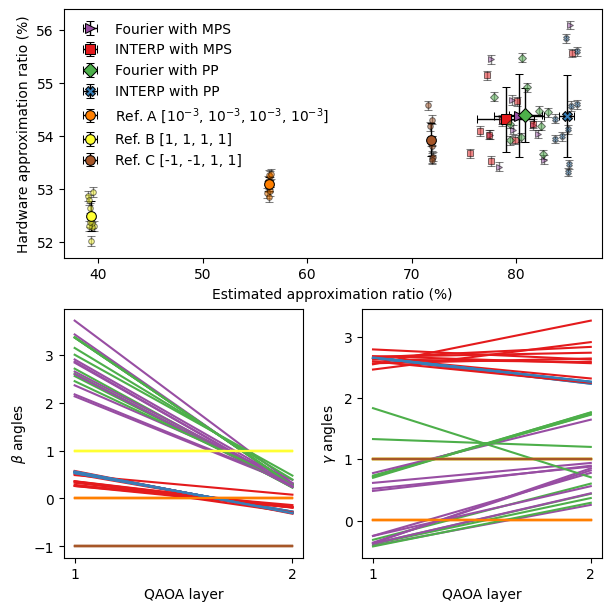

In [40]:
per_lbl_m, per_lbl_s = defaultdict(list), defaultdict(list)

per_lbl_ar = defaultdict(list)

# Goupe the data
for idx, mc_cost in enumerate(mc_costs):
    label = res_summary[idx]["metadata"]["circuit_metadata"]["method"]
    per_lbl_m[label].append(means[idx])
    per_lbl_s[label].append(sems[idx])

    inst = mc_insts[idx]
    max_cut, min_cut = m_cuts[inst]
    ar = approx_ratio(max_cut, min_cut, graphs[inst], res_summary[idx]["metadata"]["circuit_metadata"]["eval_energy"])
    per_lbl_ar[label].append(ar * 100)

fig = plt.figure(layout="constrained", figsize=(6, 6))

#fig, axs = plt.subplots(1, 1, figsize=(6, 8))

gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
# identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

axs = [ax1, ax2, ax3]

markers = {"I_MPS": "s", "I_PP": "X", "F_PP": "D", "F_MPS": ">", "zero": "o", "cal1": "o", "cal2": "o"}
colors = plt.cm.Set1.colors
colors = {"I_MPS": colors[0], "I_PP": colors[1], "F_PP": colors[2], "F_MPS": colors[3], "zero": colors[4], "cal1": colors[5], "cal2": colors[6]}
nice_labels = {
    "I_MPS": "INTERP with MPS", 
    "I_PP": "INTERP with PP", 
    "F_PP": "Fourier with PP", 
    "F_MPS": "Fourier with MPS", 
    "zero": "Ref. A [$10^{-3}$, $10^{-3}$, $10^{-3}$, $10^{-3}$]", 
    "cal1": "Ref. B [1, 1, 1, 1]", 
    "cal2": "Ref. C [-1, -1, 1, 1]",
}

counter = 0
for lbl, val in per_lbl_m.items():
    opts = {"marker": markers[lbl], "mec": "k", "mew": 0.75, "color": colors[lbl], "ls": "none", "ecolor": "k", "capsize": 3, "elinewidth": 1}
    avg_ar, std_ar = np.average(per_lbl_ar[lbl]), np.std(per_lbl_ar[lbl])
    avg_hw, std_hw = np.average(per_lbl_m[lbl]), np.std(per_lbl_m[lbl])
    axs[0].errorbar(per_lbl_ar[lbl], per_lbl_m[lbl], yerr=per_lbl_s[lbl], ms=4, alpha=0.5, **opts)
    axs[0].errorbar([avg_ar], [avg_hw], yerr=[std_hw], xerr=[std_ar], ms=7, label=nice_labels[lbl], **opts)
    counter += 1

plot_args = {
    key: {"color": colors[key]} for key in ["I_MPS", "F_MPS", "I_PP", "F_PP", "zero", "cal1", "cal2"]
}

for exec in executors:
    exec.plot_qaoa_angles(2, fig, axs[1], axs[2], plot_args=plot_args)

axs[0].legend(frameon=False)
axs[0].set_xlabel("Estimated approximation ratio (%)")
axs[0].set_ylabel("Hardware approximation ratio (%)")

for ax in [axs[1], axs[2]]:
    ax.set_xlabel("QAOA layer")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["1", "2"])

axs[1].set_ylabel("$\\beta$ angles")
axs[2].set_ylabel("$\\gamma$ angles")
fig.savefig("../figures/20260113_d5j3gd767pic73873kug_N30R3R_nighthawk.pdf", bbox_inches="tight")

#### CVaR analysis

Now, we try to look for signal in the tail of the distribution. As we will see, this is not much more telling than the mean.

In [215]:
import networkx as nx

def counts_to_maxcut_cost_cvar(graph, counts: dict, alpha=0.95):
    """Convert a dict of counts to a dict of cut values for MaxCut.

    This method computes the cost function x^T Q x.
    """
    nshots = sum(counts.values())
    adj_mat = nx.adjacency_matrix(graph, nodelist=range(graph.order())).toarray()
    cost_vals = defaultdict(float)
    vals = []

    for bit_str, count in counts.items():
        x = np.array([int(x) for x in bit_str[::-1]])
        val = float(x.T @ adj_mat @ (1 - x))
        vals += [val] * count

    vals = sorted(vals)
    q = int(alpha * len(vals))

    return np.average(vals[q:])

In [222]:
per_lbl_m = defaultdict(list)
per_lbl_ar = defaultdict(list)

# Goupe the data and compute the CVaR
for idx, mc_cost in enumerate(mc_costs):
    label = res_summary[idx]["metadata"]["circuit_metadata"]["method"]
    inst = mc_insts[idx]
    max_cut, min_cut = m_cuts[inst]
    cvar_cut = counts_to_maxcut_cost_cvar(graphs[inst], res_summary[idx]["counts"], alpha=0.9)
    cvar_ar = 100 * (cvar_cut - min_cut) / (max_cut - min_cut)
    
    per_lbl_m[label].append(cvar_ar)
    per_lbl_s[label].append(sems[idx])
    
    
    ar = approx_ratio(max_cut, min_cut, graphs[inst], res_summary[idx]["metadata"]["circuit_metadata"]["eval_energy"])
    per_lbl_ar[label].append(ar * 100)

print("Done grouping")

Done grouping


Text(0, 0.5, '$\\gamma$ angles')

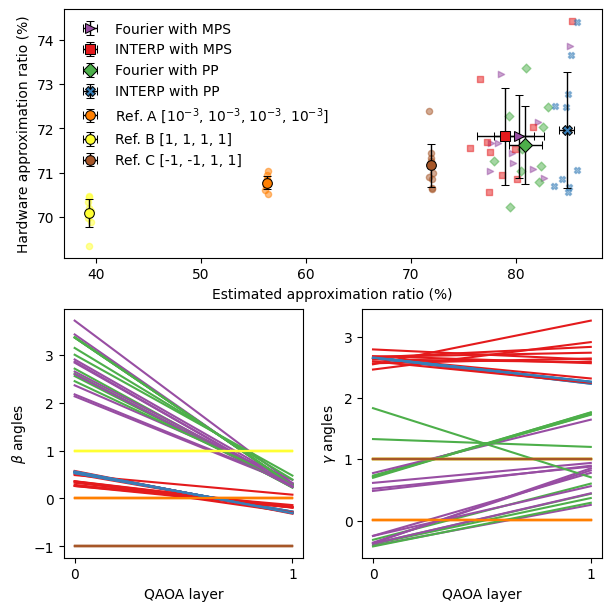

In [223]:
fig = plt.figure(layout="constrained", figsize=(6, 6))

gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

axs = [ax1, ax2, ax3]

markers = {"I_MPS": "s", "I_PP": "X", "F_PP": "D", "F_MPS": ">", "zero": "o", "cal1": "o", "cal2": "o"}
colors = plt.cm.Set1.colors
colors = {"I_MPS": colors[0], "I_PP": colors[1], "F_PP": colors[2], "F_MPS": colors[3], "zero": colors[4], "cal1": colors[5], "cal2": colors[6]}
nice_labels = {
    "I_MPS": "INTERP with MPS", 
    "I_PP": "INTERP with PP", 
    "F_PP": "Fourier with PP", 
    "F_MPS": "Fourier with MPS", 
    "zero": "Ref. A [$10^{-3}$, $10^{-3}$, $10^{-3}$, $10^{-3}$]", 
    "cal1": "Ref. B [1, 1, 1, 1]", 
    "cal2": "Ref. C [-1, -1, 1, 1]",
}

counter = 0
for lbl, val in per_lbl_m.items():
    err_opts = {"marker": markers[lbl], "mec": "k", "mew": 0.75, "color": colors[lbl], "ls": "none", "ecolor": "k", "capsize": 3, "elinewidth": 1}
    opts = {"marker": markers[lbl], "color": colors[lbl]}
    avg_ar, std_ar = np.average(per_lbl_ar[lbl]), np.std(per_lbl_ar[lbl])
    avg_hw, std_hw = np.average(per_lbl_m[lbl]), np.std(per_lbl_m[lbl])
    axs[0].scatter(per_lbl_ar[lbl], per_lbl_m[lbl], s=20, alpha=0.5, **opts)
    axs[0].errorbar([avg_ar], [avg_hw], yerr=[std_hw], xerr=[std_ar], ms=7, label=nice_labels[lbl], **err_opts)
    counter += 1

plot_args = {
    "I_PP": {"color": colors["I_PP"]},
    "I_MPS": {"color": colors["I_MPS"]},
    "F_PP": {"color": colors["F_PP"]},
    "F_MPS": {"color": colors["F_MPS"]},
    "zero": {"color": colors["zero"]},
    "cal1": {"color": colors["cal1"]},
    "cal2": {"color": colors["cal2"]},
}

for exec in executors:
    exec.plot_qaoa_angles(2, fig, axs[1], axs[2], plot_args=plot_args)

axs[0].legend(frameon=False)
axs[0].set_xlabel("Estimated approximation ratio (%)")
axs[0].set_ylabel("Hardware approximation ratio (%)")

for ax in [axs[1], axs[2]]:
    ax.set_xlabel("QAOA layer")
    ax.set_xticks([0, 1])

axs[1].set_ylabel("$\\beta$ angles")
axs[2].set_ylabel("$\\gamma$ angles")